<a href="https://colab.research.google.com/github/AbduFakir/Python-DataScience/blob/main/analyst_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np


In [13]:


df = pd.DataFrame({
    "Intern": [
        "A", "B", "C", "D", "E", "F",
        "G", "H", "I", "J", "K", "L"
    ],

    "Score": [
        5, 7, 8, 8, 12, None,
        "8  ", 7, 9, 6, 8, 7
    ],

    "Hours_Studied": [
        1, 2, 3, 3, 2, 4,
        3, 2, 5, 2, 4, 3
    ],

    "passed_exam": [
        "No", "Yes", "Yes", "Yes", "Yes", "Yes",
        "Yes", "Yes", "Yes", "No", "Yes", "Yes"
    ]
})

print(df)

   Intern Score  Hours_Studied passed_exam
0       A     5              1          No
1       B     7              2         Yes
2       C     8              3         Yes
3       D     8              3         Yes
4       E    12              2         Yes
5       F  None              4         Yes
6       G   8                3         Yes
7       H     7              2         Yes
8       I     9              5         Yes
9       J     6              2          No
10      K     8              4         Yes
11      L     7              3         Yes


In [14]:
#Remove the trailing spaces in the data.
df["Score"] = df["Score"].astype("string").str.strip()
df

,Intern,Score,Hours_Studied,passed_exam
0,A,5,1,No
1,B,7,2,Yes
2,C,8,3,Yes
3,D,8,3,Yes
4,E,12,2,Yes
5,F,<NA>,4,Yes
6,G,8,3,Yes
7,H,7,2,Yes
8,I,9,5,Yes
9,J,6,2,No


In [15]:
#make the sting to numeric

df["Score"] = pd.to_numeric(df["Score"],errors='coerce')
df

,Intern,Score,Hours_Studied,passed_exam
0,A,5,1,No
1,B,7,2,Yes
2,C,8,3,Yes
3,D,8,3,Yes
4,E,12,2,Yes
5,F,<NA>,4,Yes
6,G,8,3,Yes
7,H,7,2,Yes
8,I,9,5,Yes
9,J,6,2,No


In [16]:
print(df.isnull())

    Intern  Score  Hours_Studied  passed_exam
0    False  False          False        False
1    False  False          False        False
2    False  False          False        False
3    False  False          False        False
4    False  False          False        False
5    False   True          False        False
6    False  False          False        False
7    False  False          False        False
8    False  False          False        False
9    False  False          False        False
10   False  False          False        False
11   False  False          False        False


In [17]:
#Null imputation

median = df["Score"].median()

df["Score"] = df["Score"].fillna(median)
df

,Intern,Score,Hours_Studied,passed_exam
0,A,5,1,No
1,B,7,2,Yes
2,C,8,3,Yes
3,D,8,3,Yes
4,E,12,2,Yes
5,F,8,4,Yes
6,G,8,3,Yes
7,H,7,2,Yes
8,I,9,5,Yes
9,J,6,2,No


In [18]:
#Finding Outliers

Q1 = np.percentile(df["Score"],25)
Q3 = np.percentile(df["Score"],75)

print(Q1)
print(Q3)

7.0
8.0


In [19]:
IQR = Q3 - Q1
print(IQR)

1.0


In [20]:
upper_bound = Q3 + 1.5*IQR
lower_bound = Q1 - 1.5*IQR
print(upper_bound)
print(lower_bound)

9.5
5.5


In [21]:
outliers = df[(df["Score"]<lower_bound)|(df["Score"]>upper_bound)]
print(outliers)

  Intern  Score  Hours_Studied passed_exam
0      A      5              1          No
4      E     12              2         Yes


In [26]:
#Create a new column named Efficiency_score that tracks points scored per hour of study

df["Efficiency_Score"] = np.where(
    df["Hours_Studied"] != 0,
    df["Score"]/df["Hours_Studied"],
    0
)
df

,Intern,Score,Hours_Studied,passed_exam,Efficiency_Score
0,A,5,1,No,5.000000
1,B,7,2,Yes,3.500000
2,C,8,3,Yes,2.666667
3,D,8,3,Yes,2.666667
4,E,12,2,Yes,6.000000
5,F,8,4,Yes,2.000000
6,G,8,3,Yes,2.666667
7,H,7,2,Yes,3.500000
8,I,9,5,Yes,1.800000
9,J,6,2,No,3.000000


In [28]:
#Mean,Median,Mode

mean = np.mean(df["Score"])
median = np.median(df["Score"])
mode = df["Score"].mode()

print(mean)
print(median)
print(mode)

7.75
8.0
0    8
Name: Score, dtype: Int64


In [29]:
#Variance and Standard deviation

variance = np.var(
    df["Score"],
    ddof=0
)

std = np.std(
    df["Score"],
    ddof=0
)

print(variance)
print(std)

2.6875
1.6393596310755


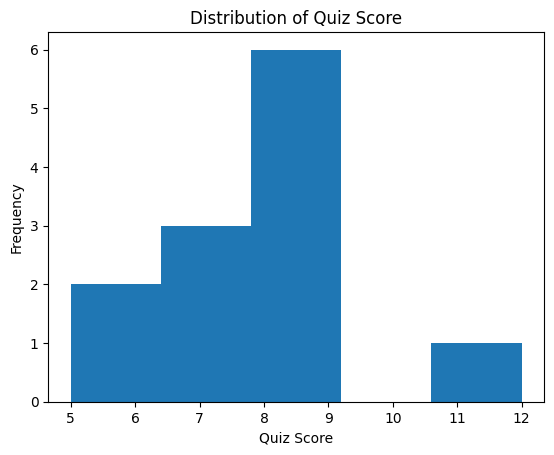

In [30]:
#Histogram

import matplotlib.pyplot as plt

plt.hist(df["Score"],bins=5)

plt.xlabel("Quiz Score")
plt.ylabel("Frequency")
plt.title("Distribution of Quiz Score")

plt.show()

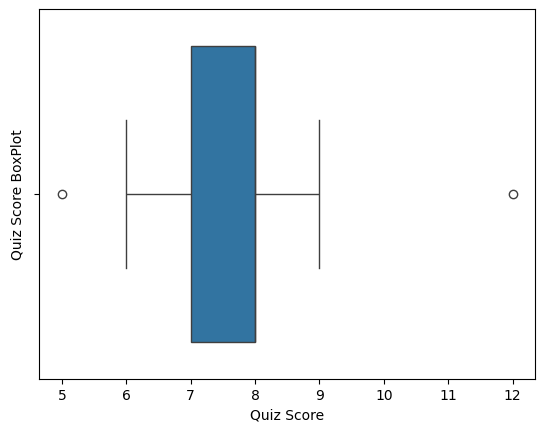

In [31]:
#Boxplot

import seaborn as sns

sns.boxplot(x=df["Score"])

plt.xlabel("Quiz Score")
plt.ylabel("Quiz Score BoxPlot")

plt.show()

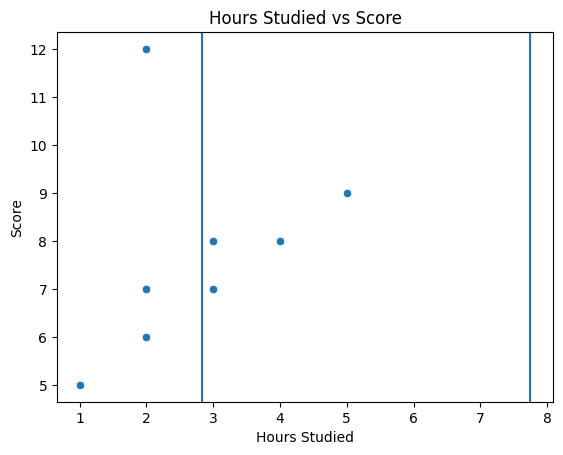

In [33]:
#Scatterplot - Hours_Studied vs Score

sns.scatterplot(
    data = df,
    x="Hours_Studied",
    y="Score"
)

mean_hours = df['Hours_Studied'].mean()
mean_score = df['Score'].mean()

plt.axvline(mean_hours)
plt.axvline(mean_score)

plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.title("Hours Studied vs Score")

plt.show()

In [35]:
#Correlation Heatmap

correlation = df.corr(numeric_only=True)
print(correlation)

                     Score  Hours_Studied  Efficiency_Score
Score             1.000000       0.357244          0.199315
Hours_Studied     0.357244       1.000000         -0.787109
Efficiency_Score  0.199315      -0.787109          1.000000


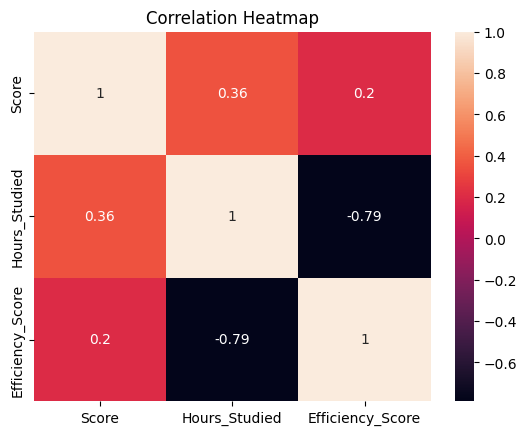

In [36]:
#heatmap

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

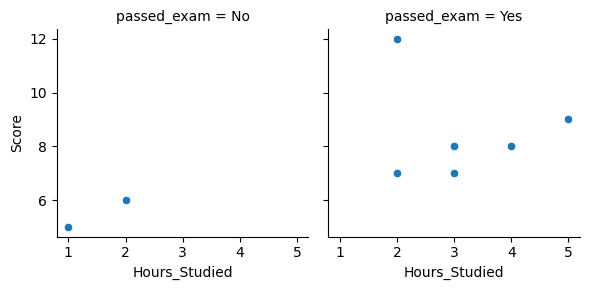

In [37]:
#FacetGrid

g = sns.FacetGrid(
    df,
    col="passed_exam"
)

g.map_dataframe(
    sns.scatterplot,
    x="Hours_Studied",
    y="Score"
)

plt.show()